# Battery Arbitrage & Operations Analysis

Battery storage operational behavior across 432 scenarios (TYNDP 2024, 2030).
Covers: storage revenue, buy/sell prices, installed capacity, hourly charging profiles,
and state-of-charge arbitrage patterns.

Extracted from sensitivity_analysis.ipynb to reduce notebook size.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

ROOT = Path('.').resolve().parent
DATA = ROOT / 'data' / 'tyndp2024' / 'preprocessed' / 'solved'
RESULTS_CSV = ROOT / 'solved_networks_core' / 'solve_results.csv'

# Load results
res = pd.read_csv(RESULTS_CSV)
res = res[res['status'] == 'solved'].copy()

# Load parquets
lmp_raw = pd.read_parquet(DATA / 'lmp.parquet')
storage_p = pd.read_parquet(DATA / 'storage_p.parquet')
storage_soc = pd.read_parquet(DATA / 'storage_soc.parquet')
static_su = pd.read_parquet(DATA / 'static_storage_units.parquet')

print(f'Scenarios: {len(res)}')
print(f'LMP: {lmp_raw.shape}')
print(f'storage_p: {storage_p.shape}')
print(f'storage_soc: {storage_soc.shape}')

## Section 7 — Storage Revenue (Implicit Arbitrage Profit)

Revenue = Σ(p_discharge × LMP) − Σ(p_charge × LMP)

Computed for a subset of networks to compare storage types and scenarios.

In [12]:
# Storage revenue by carrier for baseline subset (gas=22.68, co2=113.4, bat_scale=1, dur=1, all CYs)
baseline_tags = res[
    (res.bat_scale == 1) & (res.bat_duration == 1) &
    (res.gas_price == 22.68) & (res.co2_price == 113.4)
].sort_values("climate_year")["tag"].tolist()

# All storage units and their carriers/buses
all_su_cols = [c for c in storage_p_raw.columns if c not in ("tag", "timestamp")]
su_carrier  = static_su.loc[[c for c in all_su_cols if c in static_su.index], "carrier"]
su_bus      = static_su.loc[[c for c in all_su_cols if c in static_su.index], "bus"]

for tag in baseline_tags:
    cy = res[res.tag == tag]["climate_year"].values[0]

    sp  = storage_p_raw[storage_p_raw.tag == tag].set_index("timestamp")[all_su_cols]
    lmp = lmp_raw[lmp_raw.tag == tag].set_index("timestamp")

    revenues = {}
    for su in all_su_cols:
        if su not in su_bus.index:
            continue
        bus = su_bus[su]
        if bus not in lmp.columns:
            continue
        revenues[su] = float((sp[su] * lmp[bus]).sum())

    rev_series   = pd.Series(revenues)
    rev_by_carrier = rev_series.groupby(su_carrier.reindex(rev_series.index)).sum() / 1e6
    print(f"\nCY{int(cy)} — Storage revenue by carrier [M EUR/year]:")
    print(rev_by_carrier.sort_values(ascending=False).round(1).to_string())


CY2003 — Storage revenue by carrier [M EUR/year]:
carrier
hydro-reservoir    15938.9
hydro-phs           2651.8
hydro-phs-pure      2572.9
battery             1627.0
hydro-pondage        787.5

CY2009 — Storage revenue by carrier [M EUR/year]:
carrier
hydro-reservoir    16060.5
hydro-phs           2850.5
hydro-phs-pure      2000.1
battery             1455.2
hydro-pondage        931.7

CY2012 — Storage revenue by carrier [M EUR/year]:
carrier
hydro-reservoir    13437.8
hydro-phs-pure      3746.0
hydro-phs           3563.5
battery             2177.0
hydro-pondage        870.4


## Section 8 — Battery Buy/Sell Prices & Revenue across All Scenarios

> **Note:** This section loads all 432 networks again. To optimize, merge with Section 2 loop so each network is loaded only once.

In [13]:
# EU-wide battery buy/sell prices and revenue — all 432 scenarios from parquet
bat_p = storage_p_raw[["tag", "timestamp"] + bat_cols].copy()
bat_p["p_eu"] = bat_p[bat_cols].sum(axis=1)

merged = bat_p[["tag", "timestamp", "p_eu"]].merge(lmp_eu_avg, on=["tag", "timestamp"])

bat_records = []
for tag, grp in merged.groupby("tag"):
    p   = grp["p_eu"]
    lmp = grp["lmp_eu_avg"]
    row = res[res.tag == tag].iloc[0]

    charge_mask    = p < -0.1
    discharge_mask = p >  0.1

    buy_price  = float((lmp[charge_mask] * (-p[charge_mask])).sum() / (-p[charge_mask]).sum()) if charge_mask.any() else None
    sell_price = float((lmp[discharge_mask] * p[discharge_mask]).sum() / p[discharge_mask].sum()) if discharge_mask.any() else None
    revenue    = float((p * lmp).sum()) / 1e6
    energy_in  = float((-p[charge_mask]).sum()) / 1e6
    energy_out = float(p[discharge_mask].sum()) / 1e6

    bat_records.append({
        "tag":           tag,
        "bat_scale":     row["bat_scale"],
        "bat_duration":  row["bat_duration"],
        "gas_price":     row["gas_price"],
        "co2_price":     row["co2_price"],
        "climate_year":  row["climate_year"],
        "buy_price":     buy_price,
        "sell_price":    sell_price,
        "spread":        (sell_price - buy_price) if sell_price and buy_price else None,
        "revenue_meur":  revenue,
        "energy_in_twh":  energy_in,
        "energy_out_twh": energy_out,
    })

bat_df = pd.DataFrame(bat_records)
print(f"Done. Battery revenue range: {bat_df.revenue_meur.min():.0f} – {bat_df.revenue_meur.max():.0f} M EUR/year")
print(f"Buy price:  {bat_df.buy_price.mean():.1f} EUR/MWh (avg)")
print(f"Sell price: {bat_df.sell_price.mean():.1f} EUR/MWh (avg)")
print(f"Spread:     {bat_df.spread.mean():.1f} EUR/MWh (avg)")

Done. Battery revenue range: 599 – 2363 M EUR/year
Buy price:  52.4 EUR/MWh (avg)
Sell price: 75.3 EUR/MWh (avg)
Spread:     22.8 EUR/MWh (avg)


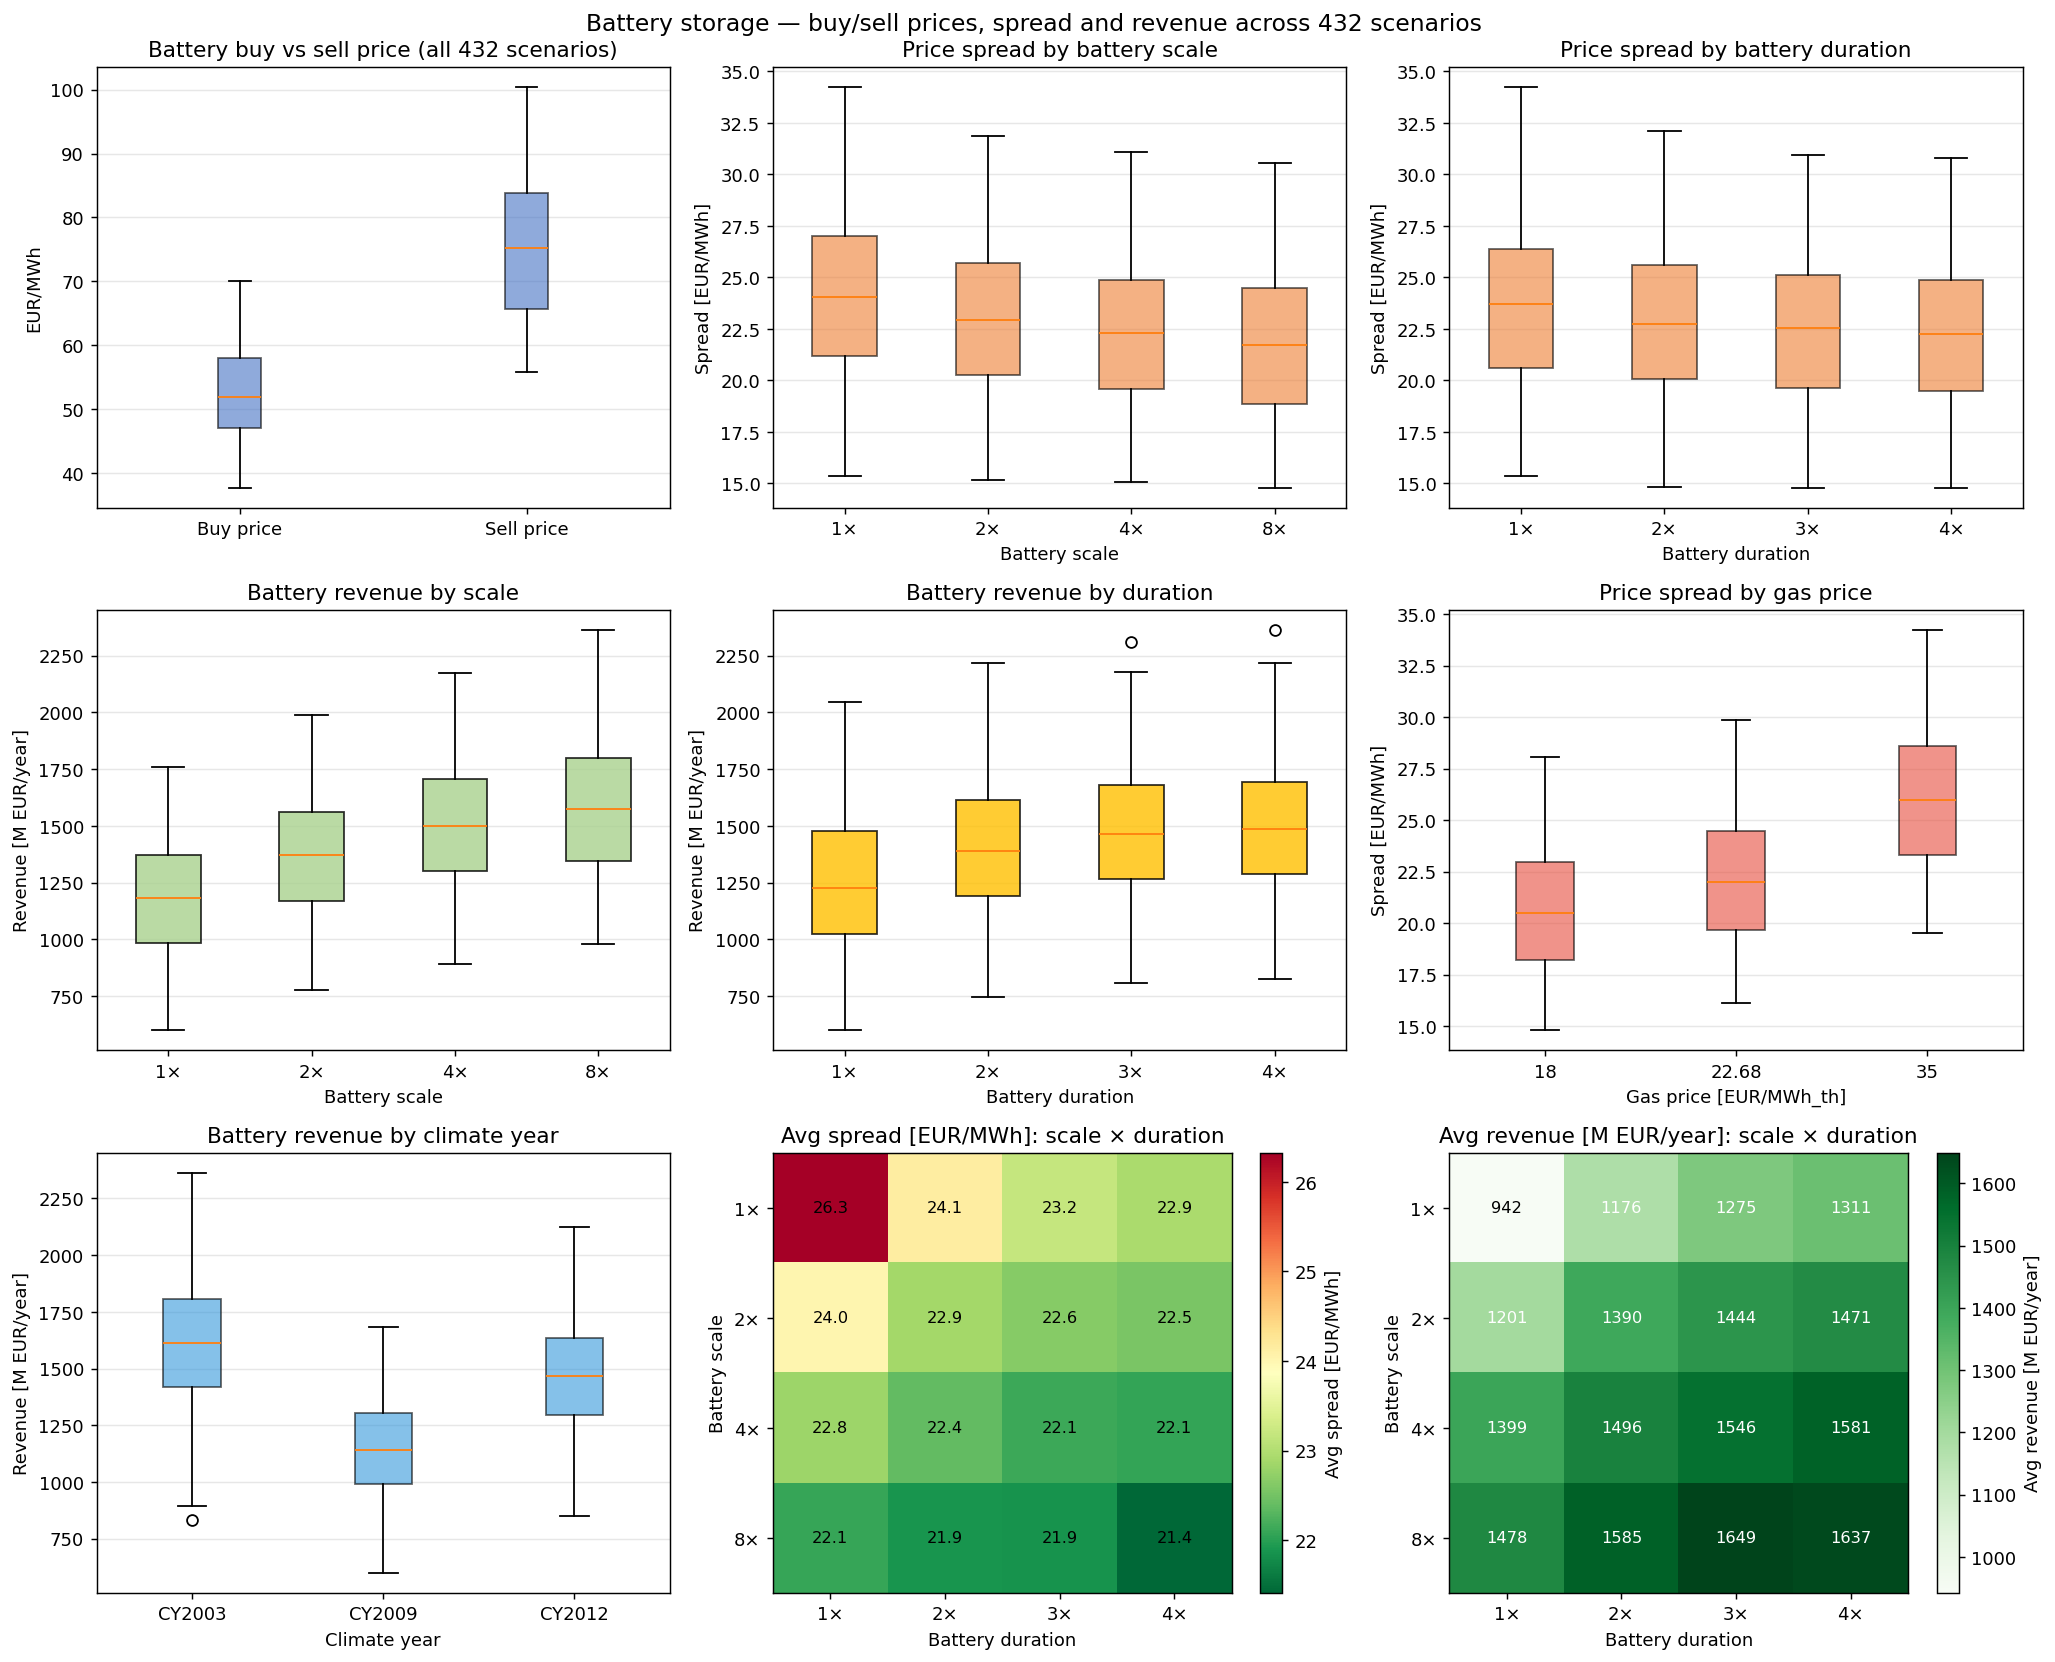

Battery revenue summary by scale:
           buy_price  sell_price  spread  revenue_meur
bat_scale                                             
1               51.1        75.2    24.1        1176.0
2               52.3        75.3    23.0        1376.4
4               53.0        75.3    22.4        1505.5
8               53.4        75.2    21.8        1587.0


In [14]:
fig, axes = plt.subplots(3, 3, figsize=(16, 13))

# 1. Boxplot: buy/sell price distribution
ax = axes[0, 0]
ax.boxplot([bat_df.buy_price.dropna(), bat_df.sell_price.dropna()],
           labels=["Buy price", "Sell price"], patch_artist=True,
           boxprops=dict(facecolor="#4472c4", alpha=0.6))
ax.set_ylabel("EUR/MWh")
ax.set_title("Battery buy vs sell price (all 432 scenarios)")
ax.grid(axis="y", alpha=0.3)

# 2. Spread by bat_scale
ax = axes[0, 1]
scales = [1, 2, 4, 8]
data = [bat_df[bat_df.bat_scale == s]["spread"].dropna() for s in scales]
ax.boxplot(data, labels=[f"{s}×" for s in scales], patch_artist=True,
           boxprops=dict(facecolor="#ed7d31", alpha=0.6))
ax.set_xlabel("Battery scale")
ax.set_ylabel("Spread [EUR/MWh]")
ax.set_title("Price spread by battery scale")
ax.grid(axis="y", alpha=0.3)

# 3. Spread by bat_duration
ax = axes[0, 2]
durations = [1, 2, 3, 4]
data = [bat_df[bat_df.bat_duration == d]["spread"].dropna() for d in durations]
ax.boxplot(data, labels=[f"{d}×" for d in durations], patch_artist=True,
           boxprops=dict(facecolor="#ed7d31", alpha=0.6))
ax.set_xlabel("Battery duration")
ax.set_ylabel("Spread [EUR/MWh]")
ax.set_title("Price spread by battery duration")
ax.grid(axis="y", alpha=0.3)

# 4. Revenue by bat_scale
ax = axes[1, 0]
data = [bat_df[bat_df.bat_scale == s]["revenue_meur"].dropna() for s in scales]
ax.boxplot(data, labels=[f"{s}×" for s in scales], patch_artist=True,
           boxprops=dict(facecolor="#a9d18e", alpha=0.8))
ax.set_xlabel("Battery scale")
ax.set_ylabel("Revenue [M EUR/year]")
ax.set_title("Battery revenue by scale")
ax.grid(axis="y", alpha=0.3)

# 5. Revenue by bat_duration
ax = axes[1, 1]
data = [bat_df[bat_df.bat_duration == d]["revenue_meur"].dropna() for d in durations]
ax.boxplot(data, labels=[f"{d}×" for d in durations], patch_artist=True,
           boxprops=dict(facecolor="#ffc000", alpha=0.8))
ax.set_xlabel("Battery duration")
ax.set_ylabel("Revenue [M EUR/year]")
ax.set_title("Battery revenue by duration")
ax.grid(axis="y", alpha=0.3)

# 6. Spread by gas_price
ax = axes[1, 2]
gas_prices = [18, 22.68, 35]
data = [bat_df[bat_df.gas_price == g]["spread"].dropna() for g in gas_prices]
ax.boxplot(data, labels=[str(g) for g in gas_prices], patch_artist=True,
           boxprops=dict(facecolor="#e74c3c", alpha=0.6))
ax.set_xlabel("Gas price [EUR/MWh_th]")
ax.set_ylabel("Spread [EUR/MWh]")
ax.set_title("Price spread by gas price")
ax.grid(axis="y", alpha=0.3)

# 7. Revenue by climate year
ax = axes[2, 0]
cys = [2003, 2009, 2012]
data = [bat_df[bat_df.climate_year == cy]["revenue_meur"].dropna() for cy in cys]
ax.boxplot(data, labels=[f"CY{cy}" for cy in cys], patch_artist=True,
           boxprops=dict(facecolor="#3498db", alpha=0.6))
ax.set_xlabel("Climate year")
ax.set_ylabel("Revenue [M EUR/year]")
ax.set_title("Battery revenue by climate year")
ax.grid(axis="y", alpha=0.3)

# 8. Heatmapa: scale x duration -> spread
ax = axes[2, 1]
matrix = np.zeros((len(scales), len(durations)))
for i, s in enumerate(scales):
    for j, d in enumerate(durations):
        matrix[i, j] = bat_df[(bat_df.bat_scale == s) & (bat_df.bat_duration == d)]["spread"].mean()
im = ax.imshow(matrix, cmap="RdYlGn_r", aspect="auto")
plt.colorbar(im, ax=ax, label="Avg spread [EUR/MWh]")
ax.set_xticks(range(len(durations)))
ax.set_yticks(range(len(scales)))
ax.set_xticklabels([f"{d}×" for d in durations])
ax.set_yticklabels([f"{s}×" for s in scales])
ax.set_xlabel("Battery duration")
ax.set_ylabel("Battery scale")
ax.set_title("Avg spread [EUR/MWh]: scale × duration")
for i in range(len(scales)):
    for j in range(len(durations)):
        ax.text(j, i, f"{matrix[i,j]:.1f}", ha="center", va="center", fontsize=9)

# 9. Heatmapa: scale x duration -> revenue
ax = axes[2, 2]
matrix_rev = np.zeros((len(scales), len(durations)))
for i, s in enumerate(scales):
    for j, d in enumerate(durations):
        matrix_rev[i, j] = bat_df[(bat_df.bat_scale == s) & (bat_df.bat_duration == d)]["revenue_meur"].mean()
im2 = ax.imshow(matrix_rev, cmap="Greens", aspect="auto")
plt.colorbar(im2, ax=ax, label="Avg revenue [M EUR/year]")
ax.set_xticks(range(len(durations)))
ax.set_yticks(range(len(scales)))
ax.set_xticklabels([f"{d}×" for d in durations])
ax.set_yticklabels([f"{s}×" for s in scales])
ax.set_xlabel("Battery duration")
ax.set_ylabel("Battery scale")
ax.set_title("Avg revenue [M EUR/year]: scale × duration")
for i in range(len(scales)):
    for j in range(len(durations)):
        ax.text(j, i, f"{matrix_rev[i,j]:.0f}", ha="center", va="center", fontsize=9,
                color="white" if matrix_rev[i,j] > matrix_rev.max()*0.6 else "black")

fig.suptitle("Battery storage — buy/sell prices, spread and revenue across 432 scenarios", fontsize=13)
plt.tight_layout()
plt.show()

print("Battery revenue summary by scale:")
print(bat_df.groupby("bat_scale")[["buy_price","sell_price","spread","revenue_meur"]].mean().round(1).to_string())


## Section 9 — Battery Installed Capacity by Scale × Duration

Static analysis — loads 16 networks (4 scale × 4 duration, fixed gas/co2/cy).
Shows total EU capacity [GW / GWh] and per-bus breakdown.

In [15]:
# Battery installed capacity by scale × duration — from static_storage_units + manifest
# (network structure is identical across scenarios, only dispatch changes)
FIX_GAS = 22.68
FIX_CO2 = 113.4
FIX_CY  = 2009
SCALES    = [1, 2, 4, 8]
DURATIONS = [1, 2, 3, 4]

manifest = pd.read_parquet(PREPROCESSED / "manifest.parquet")
bats = static_su[static_su.carrier == "battery"].copy()

cap_records = []
bus_records = []

for s in SCALES:
    for d in DURATIONS:
        tag = manifest[
            (manifest.battery_scale == s) & (manifest.battery_duration == d) &
            (manifest.gas_price == FIX_GAS) & (manifest.co2_price == FIX_CO2) &
            (manifest.climate_year == FIX_CY)
        ]["tag"].values
        if len(tag) == 0:
            print(f"Missing: scale={s} dur={d}")
            continue
        tag = tag[0]

        # static_storage_units is from the first network — p_nom is scaled
        # we need to load one .nc per scale×duration to get actual p_nom
        # (bat_scale changes p_nom, bat_duration changes max_hours)
        # Load from solved network
        nc_path = SOLVED_DIR / f"{tag}.nc"
        if not nc_path.exists():
            print(f"Missing .nc: {tag}")
            continue
        n = pypsa.Network()
        n.import_from_netcdf(str(nc_path))
        b = n.storage_units[n.storage_units.carrier == "battery"]

        total_mw  = b.p_nom.sum() / 1e3
        total_mwh = (b.p_nom * b.max_hours).sum() / 1e3
        cap_records.append({
            "bat_scale": s, "bat_duration": d,
            "total_gw":  round(total_mw, 1),
            "total_gwh": round(total_mwh, 1),
            "avg_hours": round(total_mwh / total_mw, 2) if total_mw > 0 else None,
        })
        per_bus = b.groupby("bus").agg(
            mw  =("p_nom", "sum"),
            mwh =("p_nom", lambda x: (x * b.loc[x.index, "max_hours"]).sum())
        ) / 1e3
        per_bus["bat_scale"] = s
        per_bus["bat_duration"] = d
        bus_records.append(per_bus.reset_index())

cap_df = pd.DataFrame(cap_records)
bus_df = pd.concat(bus_records, ignore_index=True)

print("=== Total EU battery capacity [GW] ===")
print(cap_df.pivot(index="bat_scale", columns="bat_duration", values="total_gw").to_string())
print()
print("=== Total EU battery energy [GWh] ===")
print(cap_df.pivot(index="bat_scale", columns="bat_duration", values="total_gwh").to_string())
print()
print("=== Average duration [h] ===")
print(cap_df.pivot(index="bat_scale", columns="bat_duration", values="avg_hours").to_string())

INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'TYNDP2024_Electricity_2030' has buses, carriers, generators, links, loads, storage_units, sub_networks
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'TYNDP2024_Electricity_2030' has buses, carriers, generators, links, loads, storage_units, sub_networks
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'TYNDP2024_Electricity_2030' has buses, carriers, generators, links, loads, storage_units, sub_networks
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'TYNDP2024_Electricity_2030' has buses, carriers, generators, links, loads, storage_units, sub_networks
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'TYNDP2024_Electricity_2030' has buses, carriers,

=== Total EU battery capacity [GW] ===
bat_duration      1      2      3      4
bat_scale                               
1              62.3   62.3   62.3   62.3
2             124.7  124.7  124.7  124.7
4             249.3  249.3  249.3  249.3
8             498.6  498.6  498.6  498.6

=== Total EU battery energy [GWh] ===
bat_duration       1       2       3       4
bat_scale                                   
1              208.0   336.7   418.1   461.8
2              416.0   673.3   836.2   923.6
4              832.0  1346.7  1672.3  1847.2
8             1664.1  2693.4  3344.6  3694.4

=== Average duration [h] ===
bat_duration     1    2     3     4
bat_scale                          
1             3.34  5.4  6.71  7.41
2             3.34  5.4  6.71  7.41
4             3.34  5.4  6.71  7.41
8             3.34  5.4  6.71  7.41


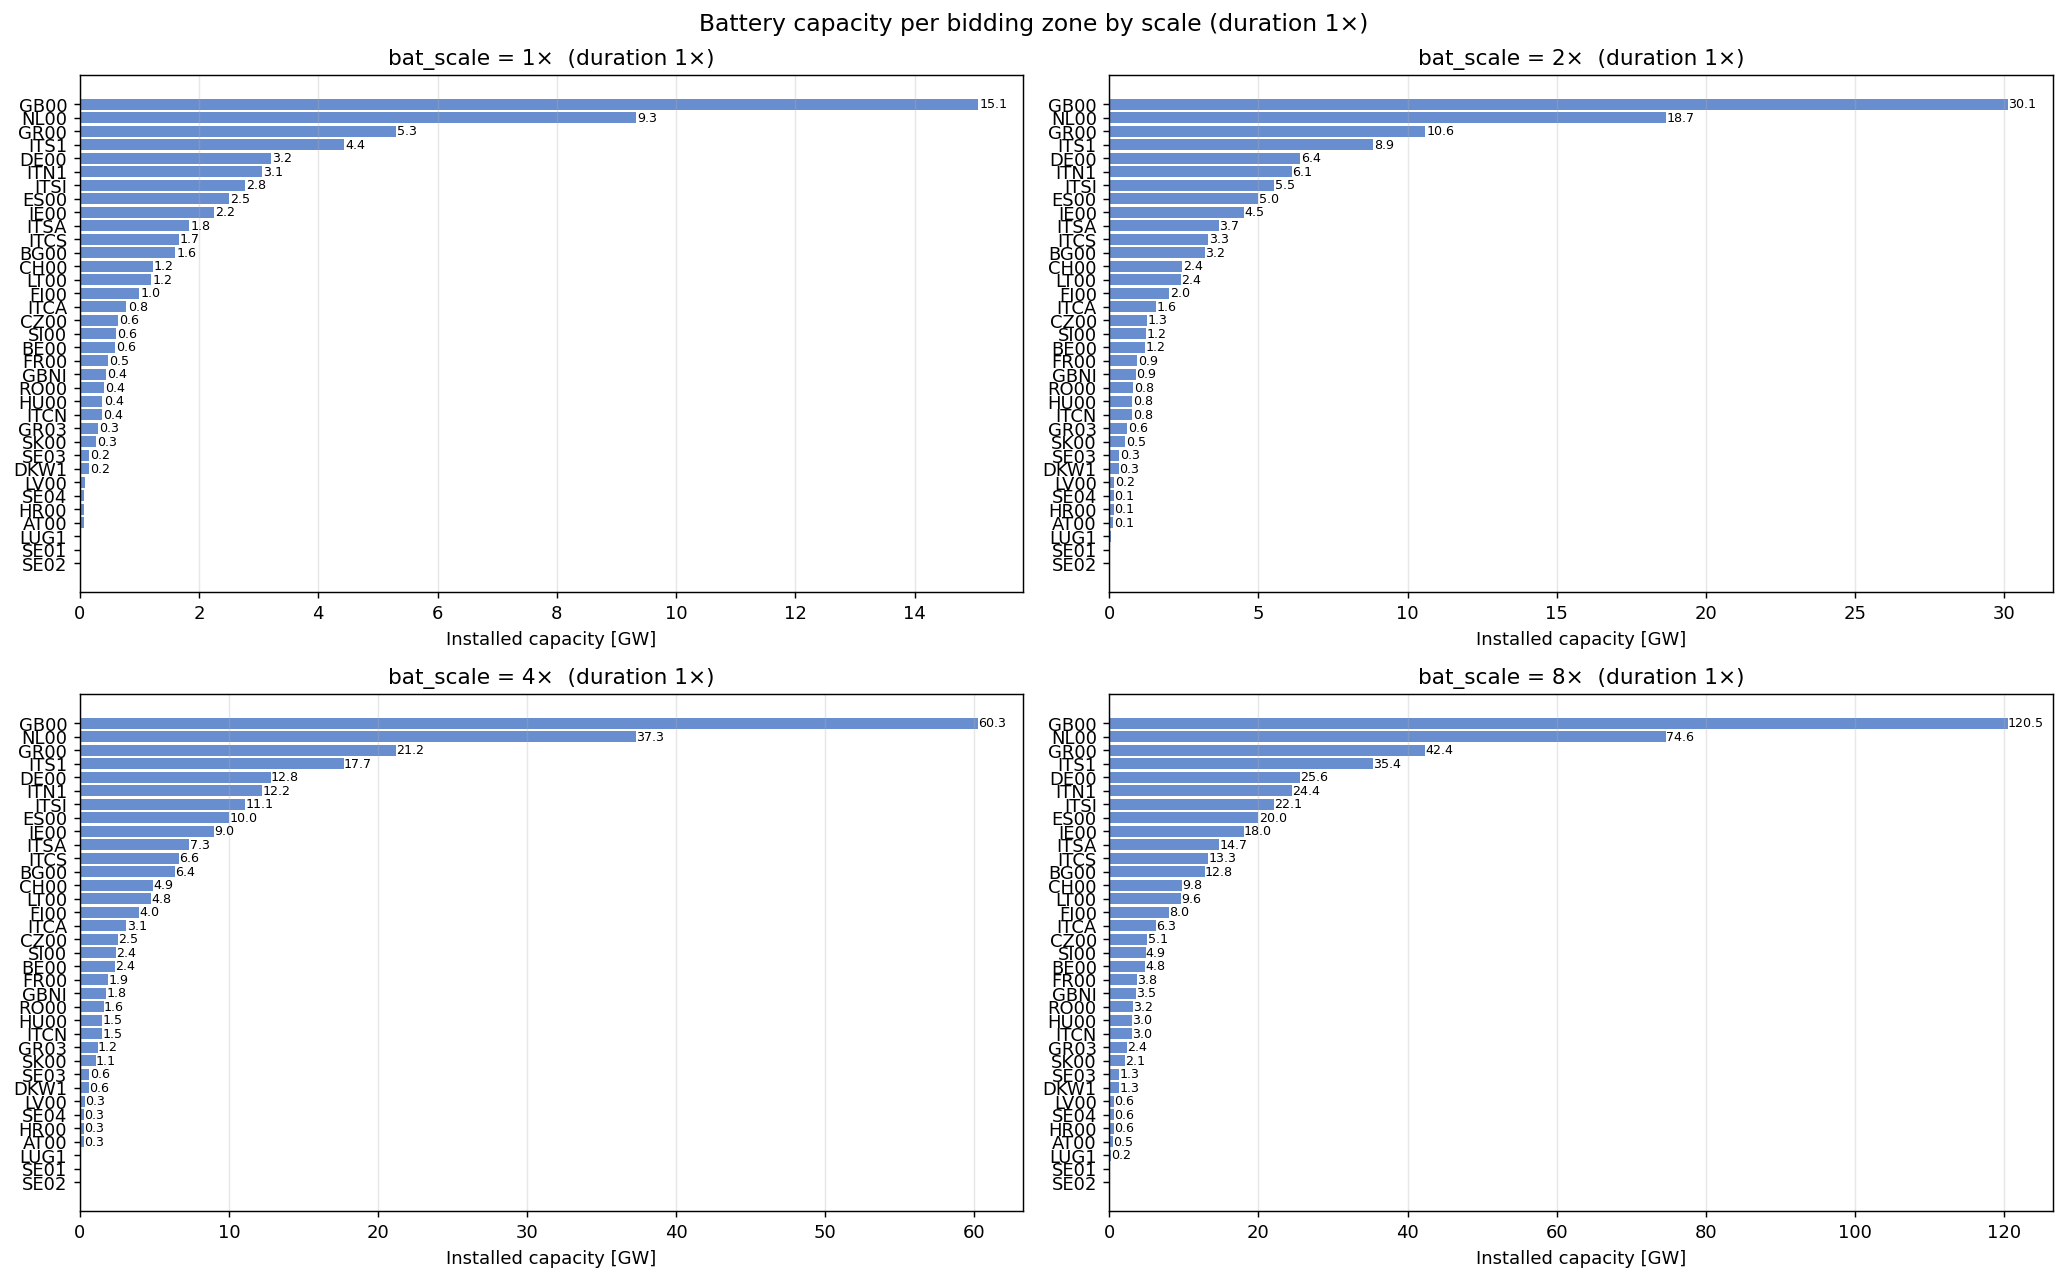

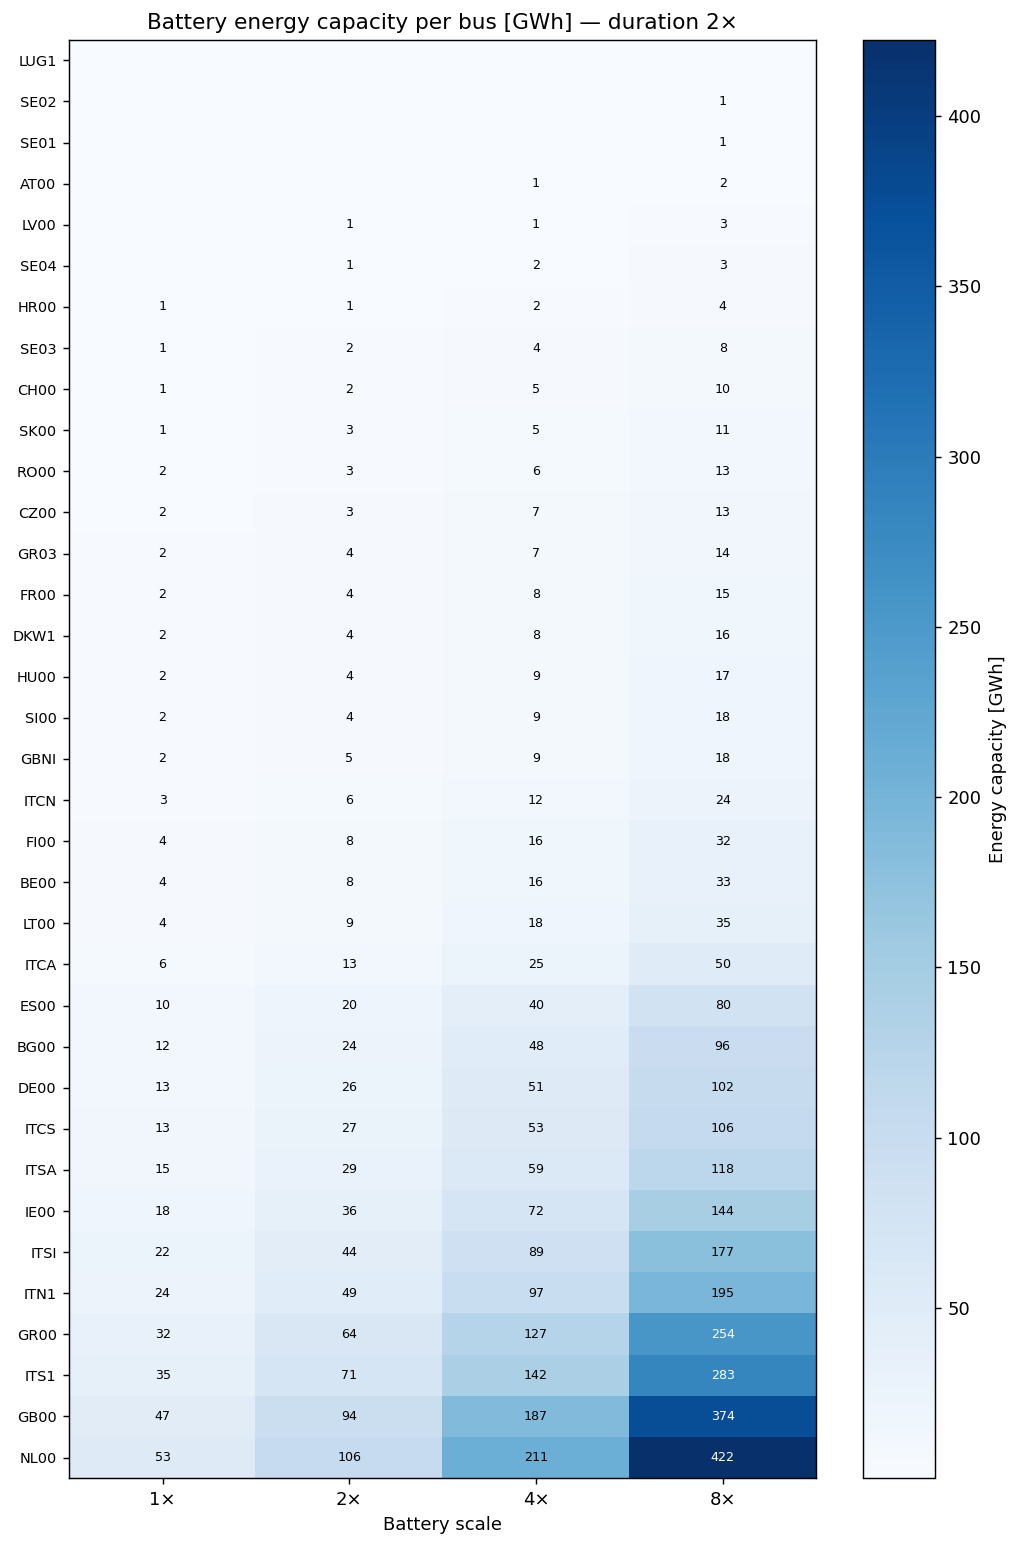

In [16]:
# Per-bus capacity for each bat_scale (fixed duration=1x)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, s in zip(axes, SCALES):
    sub = bus_df[(bus_df.bat_scale == s) & (bus_df.bat_duration == 1)].sort_values("mw", ascending=True)
    ax.barh(sub["bus"], sub["mw"], color="#4472c4", alpha=0.8)
    ax.set_title(f"bat_scale = {s}×  (duration 1×)")
    ax.set_xlabel("Installed capacity [GW]")
    ax.grid(axis="x", alpha=0.3)
    for i, (_, row) in enumerate(sub.iterrows()):
        if row["mw"] > 0.1:
            ax.text(row["mw"] + 0.02, i, f"{row['mw']:.1f}", va="center", fontsize=7)

fig.suptitle("Battery capacity per bidding zone by scale (duration 1×)", fontsize=13)
plt.tight_layout()
plt.show()

# Heatmap: GWh per bus × bat_scale (fixed duration=2x)
pivot = bus_df[bus_df.bat_duration == 2].pivot_table(
    index="bus", columns="bat_scale", values="mwh", aggfunc="sum"
).fillna(0).sort_values(4, ascending=True)

fig, ax = plt.subplots(figsize=(8, 12))
im = ax.imshow(pivot.values, cmap="Blues", aspect="auto")
plt.colorbar(im, ax=ax, label="Energy capacity [GWh]")
ax.set_xticks(range(len(SCALES)))
ax.set_xticklabels([f"{s}×" for s in SCALES])
ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(pivot.index, fontsize=8)
ax.set_xlabel("Battery scale")
ax.set_title("Battery energy capacity per bus [GWh] — duration 2×")
for i in range(len(pivot)):
    for j in range(len(SCALES)):
        val = pivot.values[i, j]
        if val > 0.5:
            ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=7,
                    color="white" if val > pivot.values.max()*0.6 else "black")
plt.tight_layout()
plt.show()


## Section 10 — Battery Hourly Charging Profile (Europe-wide)

Representative subset: gas=22.68 €/MWh_th, co2=113.4 €/tCO₂, duration=2×, all bat_scales (1/2/4/8×) × all climate years (2003/2009/2012) = **12 networks**.

`storage_units_t.p` convention: positive = discharge, negative = charge.

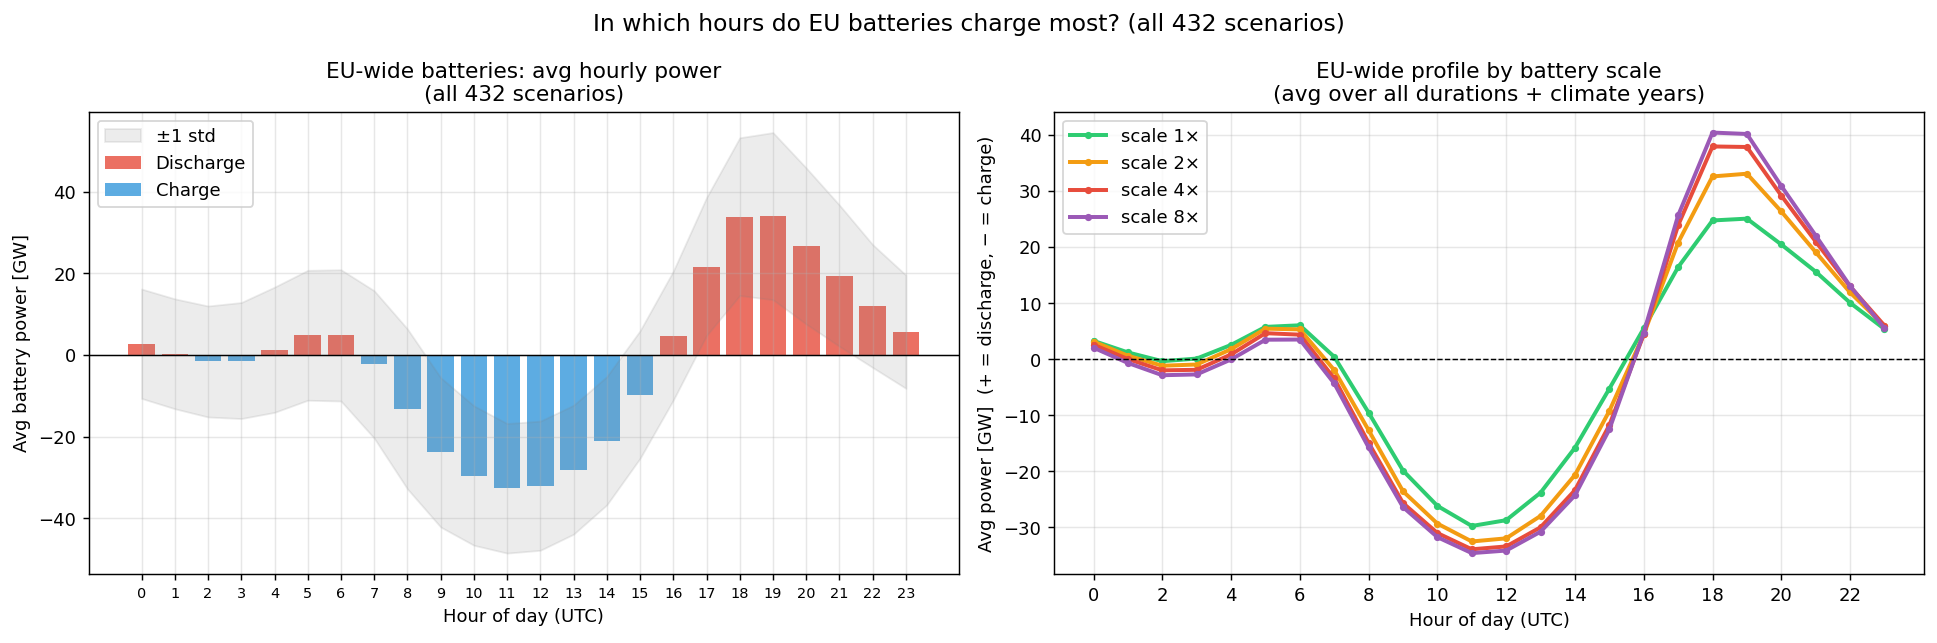


Peak CHARGE hour:    11h → -32.7 GW
Peak DISCHARGE hour: 19h → 34.0 GW


In [17]:
# EU-wide hourly battery charging profile — all 432 scenarios from parquet
bat_p_eu = storage_p_raw[["tag", "timestamp"] + bat_cols].copy()
bat_p_eu["p_eu"] = bat_p_eu[bat_cols].sum(axis=1) / 1e3  # GW
bat_p_eu["hour"] = bat_p_eu["timestamp"].dt.hour

# Add scenario metadata
bat_p_eu = bat_p_eu.merge(res[["tag", "bat_scale", "climate_year"]], on="tag")

# Average hourly profile across ALL 432 scenarios
hourly_all = bat_p_eu.groupby("hour")["p_eu"].mean()
hourly_std = bat_p_eu.groupby("hour")["p_eu"].std()

# Average hourly profile by bat_scale (averaged over all other dims)
hourly_by_scale = bat_p_eu.groupby(["bat_scale", "hour"])["p_eu"].mean().unstack(level=0)

hours = np.arange(24)
scale_colors = {1: "#2ecc71", 2: "#f39c12", 4: "#e74c3c", 8: "#9b59b6"}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.bar(hours, hourly_all.clip(lower=0).values, color="#e74c3c", alpha=0.8, label="Discharge")
ax.bar(hours, hourly_all.clip(upper=0).values, color="#3498db", alpha=0.8, label="Charge")
ax.fill_between(hours,
                (hourly_all - hourly_std).values,
                (hourly_all + hourly_std).values,
                alpha=0.15, color="grey", label="±1 std")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("Avg battery power [GW]")
ax.set_title("EU-wide batteries: avg hourly power\n(all 432 scenarios)")
ax.legend()
ax.grid(alpha=0.3)
ax.set_xticks(hours)
ax.set_xticklabels(hours, fontsize=8)

ax = axes[1]
for scale, color in scale_colors.items():
    if scale in hourly_by_scale.columns:
        ax.plot(hours, hourly_by_scale[scale].values, color=color, linewidth=2.2,
                marker="o", markersize=3, label=f"scale {scale}×")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("Avg power [GW]  (+ = discharge, − = charge)")
ax.set_title("EU-wide profile by battery scale\n(avg over all durations + climate years)")
ax.legend()
ax.grid(alpha=0.3)
ax.set_xticks(range(0, 24, 2))

fig.suptitle("In which hours do EU batteries charge most? (all 432 scenarios)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nPeak CHARGE hour:    {hourly_all.idxmin()}h → {hourly_all.min():.1f} GW")
print(f"Peak DISCHARGE hour: {hourly_all.idxmax()}h → {hourly_all.max():.1f} GW")

## Section 21 — Battery SOC Arbitrage Patterns

`storage_soc.parquet` has not been used yet. State-of-charge profiles show
*when* batteries charge and discharge — revealing the actual arbitrage mechanism.

Subset: gas=22.68, co2=113.4, bat_scale∈[1,8], all 3 climate years (6 scenarios).


In [35]:
# Load storage_soc for a small subset
soc_file = PREPROCESSED / "storage_soc.parquet"

subset_tags = res_vol[
    (res_vol.gas_price == 22.68) & (res_vol.co2_price == 113.4) &
    (res_vol.bat_scale.isin([1, 8])) & (res_vol.bat_duration == 1)
]["tag"].tolist()

print(f"Loading SOC for {len(subset_tags)} scenarios: {subset_tags}")

soc_raw = pd.read_parquet(soc_file, filters=[("tag", "in", subset_tags)])
soc_raw["timestamp"] = pd.to_datetime(soc_raw["timestamp"])
print(f"SOC shape: {soc_raw.shape}")
print(f"SOC columns (first 10): {soc_raw.columns[:10].tolist()}")

# Find battery SOC columns (same units as bat_cols)
soc_bat_cols = [c for c in soc_raw.columns if c in bat_cols]
soc_de_cols  = [c for c in soc_bat_cols if bat_bus.get(c) == "DE00"]
print(f"Battery SOC units: {len(soc_bat_cols)} total, {len(soc_de_cols)} DE00")

# EU-wide total SOC (sum all battery units)
soc_raw["soc_eu"]  = soc_raw[soc_bat_cols].sum(axis=1)
soc_raw["soc_de"]  = soc_raw[soc_de_cols].sum(axis=1) if soc_de_cols else 0.0
soc_raw["hour"]    = soc_raw["timestamp"].dt.hour
soc_raw["month"]   = soc_raw["timestamp"].dt.month
soc_raw["dayofyear"] = soc_raw["timestamp"].dt.dayofyear

soc_meta = soc_raw.merge(
    res_vol[["tag","bat_scale","climate_year"]],
    on="tag"
)
print("Merged. Unique scenarios:", soc_meta["tag"].nunique())


Loading SOC for 6 scenarios: ['bat1x_gas22.68_co2_113.4_cy2003_dur1x', 'bat8x_gas22.68_co2_113.4_cy2003_dur1x', 'bat1x_gas22.68_co2_113.4_cy2009_dur1x', 'bat8x_gas22.68_co2_113.4_cy2009_dur1x', 'bat1x_gas22.68_co2_113.4_cy2012_dur1x', 'bat8x_gas22.68_co2_113.4_cy2012_dur1x']
SOC shape: (52560, 121)
SOC columns (first 10): ['tag', 'timestamp', 'AL00-hydro-reservoir', 'AT00-battery', 'AT00-hydro-phs', 'AT00-hydro-phs-pure', 'AT00-hydro-pondage', 'AT00-hydro-reservoir', 'BA00-hydro-phs', 'BA00-hydro-pondage']
Battery SOC units: 35 total, 1 DE00
Merged. Unique scenarios: 6


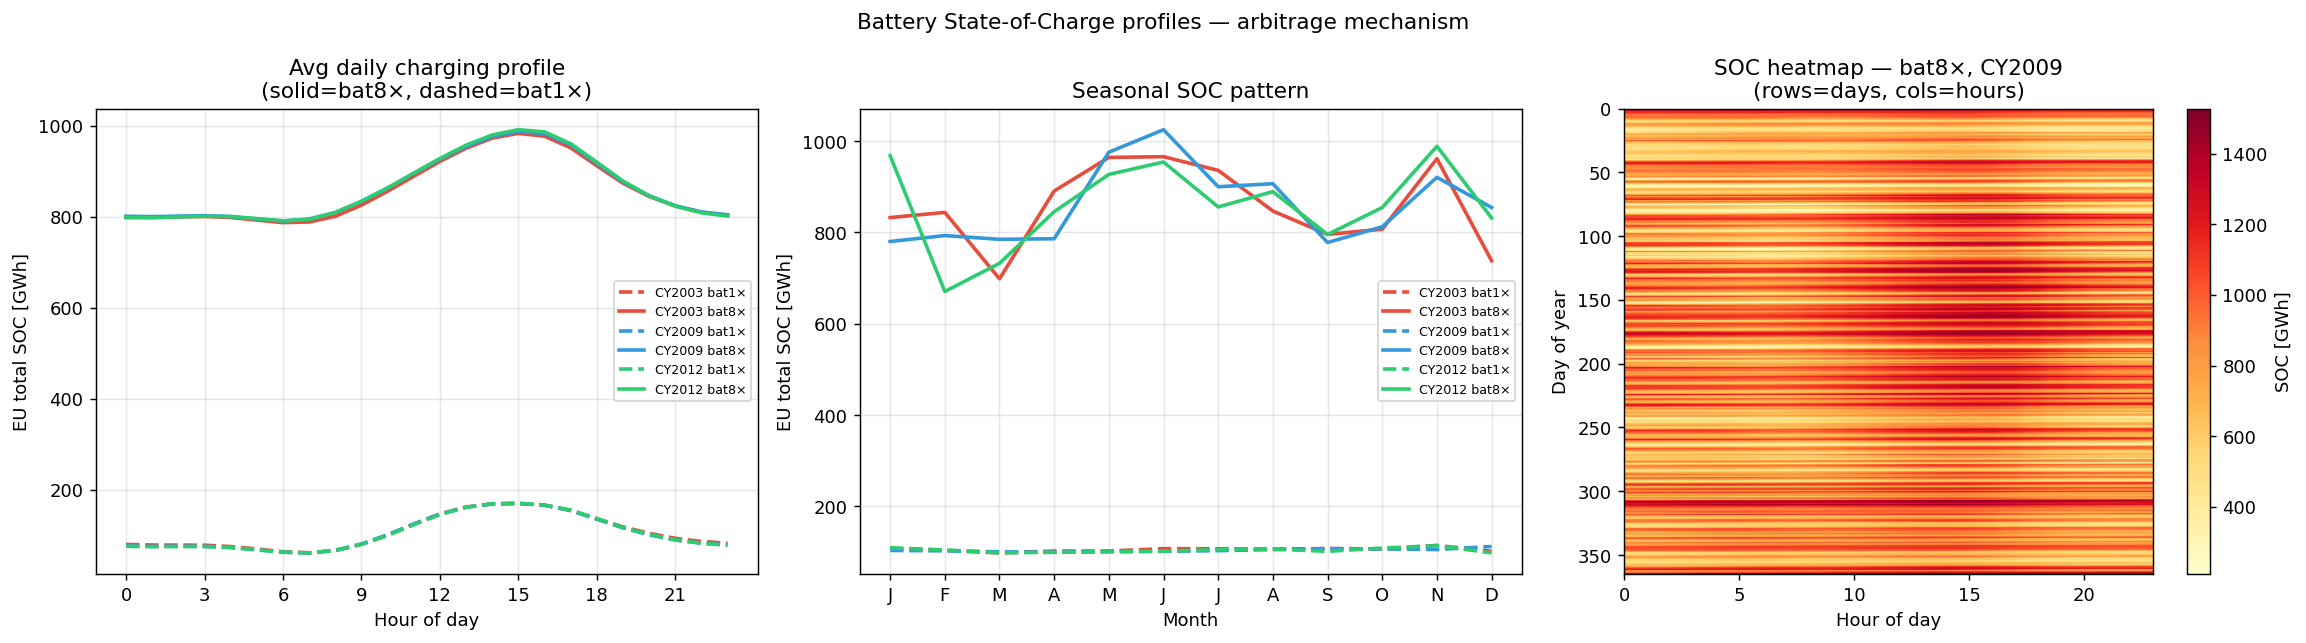


Avg daily SOC swing (max-min per day):
  CY2003 bat1×: 123.06 GWh/day avg swing
  CY2003 bat8×: 288.99 GWh/day avg swing
  CY2009 bat1×: 123.87 GWh/day avg swing
  CY2009 bat8×: 296.11 GWh/day avg swing
  CY2012 bat1×: 126.03 GWh/day avg swing
  CY2012 bat8×: 304.28 GWh/day avg swing


In [36]:
cy_colors = {2003:"#e74c3c", 2009:"#3498db", 2012:"#2ecc71"}
scale_ls   = {1:"--", 8:"-"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Average hourly SOC profile (hour of day)
ax = axes[0]
for cy in cy_list:
    for s in [1, 8]:
        sub = soc_meta[(soc_meta.climate_year==cy) & (soc_meta.bat_scale==s)]
        if sub.empty: continue
        hourly = sub.groupby("hour")["soc_eu"].mean() / 1e3  # GWh
        ax.plot(hourly.index, hourly.values,
                color=cy_colors[cy], linestyle=scale_ls[s], linewidth=2,
                label=f"CY{cy} bat{s}×")
ax.set_xlabel("Hour of day"); ax.set_ylabel("EU total SOC [GWh]")
ax.set_title("Avg daily charging profile\n(solid=bat8×, dashed=bat1×)")
ax.legend(fontsize=7); ax.grid(alpha=0.3); ax.set_xticks(range(0,24,3))

# 2. Monthly average SOC
ax = axes[1]
month_labels = ["J","F","M","A","M","J","J","A","S","O","N","D"]
for cy in cy_list:
    for s in [1, 8]:
        sub = soc_meta[(soc_meta.climate_year==cy) & (soc_meta.bat_scale==s)]
        if sub.empty: continue
        monthly = sub.groupby("month")["soc_eu"].mean() / 1e3
        ax.plot(monthly.index, monthly.values,
                color=cy_colors[cy], linestyle=scale_ls[s], linewidth=2,
                label=f"CY{cy} bat{s}×")
ax.set_xlabel("Month"); ax.set_ylabel("EU total SOC [GWh]")
ax.set_title("Seasonal SOC pattern")
ax.set_xticks(range(1,13)); ax.set_xticklabels(month_labels)
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# 3. SOC heatmap — day of year × hour (bat8x, CY2009)
ax = axes[2]
sub_hm = soc_meta[(soc_meta.climate_year==2009) & (soc_meta.bat_scale==8)]
if not sub_hm.empty:
    pivot = sub_hm.pivot_table(index="dayofyear", columns="hour", values="soc_eu", aggfunc="mean")
    pivot_gwh = pivot / 1e3
    im = ax.imshow(pivot_gwh.values, aspect="auto", cmap="YlOrRd",
                   extent=[0, 23, 365, 0])
    plt.colorbar(im, ax=ax, label="SOC [GWh]")
    ax.set_xlabel("Hour of day"); ax.set_ylabel("Day of year")
    ax.set_title("SOC heatmap — bat8×, CY2009\n(rows=days, cols=hours)")

fig.suptitle("Battery State-of-Charge profiles — arbitrage mechanism", fontsize=12)
plt.tight_layout()
plt.show()

# Daily SOC swing comparison CY2003 vs CY2012
print("\nAvg daily SOC swing (max-min per day):")
for cy in cy_list:
    for s in [1, 8]:
        sub = soc_meta[(soc_meta.climate_year==cy) & (soc_meta.bat_scale==s)]
        if sub.empty: continue
        swing = sub.groupby(sub["timestamp"].dt.date)["soc_eu"].agg(lambda x: x.max()-x.min()).mean()/1e3
        print(f"  CY{cy} bat{s}×: {swing:.2f} GWh/day avg swing")
